# STEP 4. After EDA : Offer Attribute Analysis & Statistical Validation

## 노트북 개요

본 노트북은 스타벅스 앱 오퍼 라이프사이클 분석의 후반부 단계로,  
EDA를 통해 발견한 **오퍼 반응 이탈 패턴**을 바탕으로  
① 오퍼 자체의 설계 요인,  
② 고객 × 오퍼의 조건부 실패 구조,  
③ 핵심 관계에 대한 통계적 검증  
을 순차적으로 수행하는 것을 목표로 한다.


## 본 노트북의 최종 목표

- 오퍼 실패가 발생하는 **구조적 조건**을 명확히 설명한다.
- 이탈 예측 모델링에 사용할 **핵심 변수 후보군**을 정제한다.
- “오퍼는 누구에게, 언제, 어떻게 실패하는가?”에 대해  
  데이터로 방어 가능한 답을 제시한다.

0) 규칙 먼저 고정 <br>
	•	분석 단위: person × offer<br>
	•	오퍼 퍼널 컬럼: received / viewed / completed (boolean)<br>
	•	STEP 1(오퍼 단독 분석) 타겟: viewed == True 중 completed == False의 비율(= Viewed→Completed 이탈률)<br>
	•	offer_id는 transcript의 value에서 뽑고, portfolio와 조인해서 오퍼 속성을 붙임

---
### (둘째날 EDA : 첫째날 분석한 거 다시한번 컨펌 요약)

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

def set_korean_font():
    # Mac에서 흔한 한글 폰트 후보
    candidates = [
        "Apple SD Gothic Neo",
        "AppleGothic",
        "NanumGothic",
        "Malgun Gothic",
        "Noto Sans CJK KR",
        "Noto Sans KR",
    ]
    available = {f.name for f in fm.fontManager.ttflist}

    for name in candidates:
        if name in available:
            mpl.rcParams["font.family"] = name
            mpl.rcParams["axes.unicode_minus"] = False
            print(f"[OK] font set to: {name}")
            return True

    print("[WARN] Korean font not found. Use English labels to avoid glyph warnings.")
    return False

_ = set_korean_font()
plt.close("all")

[OK] font set to: Apple SD Gothic Neo


In [5]:
# 데이터로드 + offer 이벤트만 뽑기
import pandas as pd
import numpy as np

# 1) raw 로드
profile = pd.read_json("../data/raw/profile.json", orient="records", lines=True)
portfolio = pd.read_json("../data/raw/portfolio.json", orient="records", lines=True)
transcript = pd.read_json("../data/raw/transcript.json", orient="records", lines=True)

print(profile.shape, portfolio.shape, transcript.shape)
display(profile.head(2))
display(portfolio.head(2))
display(transcript.head(2))

(17000, 5) (10, 6) (306534, 4)


,gender,age,id,became_member_on,income
0,None,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0


,reward,channels,difficulty,duration,offer_type,id
0,10,"[email, mobile, social]",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,10,"[web, email, mobile, social]",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0


,person,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0


In [6]:
# 2) offer 이벤트만
offer_events = transcript[transcript["event"].isin(["offer received", "offer viewed", "offer completed"])].copy()

# 3) offer_id 추출 함수
def extract_offer_id(v):
    if isinstance(v, dict):
        return v.get("offer id") or v.get("offer_id")
    return None

offer_events["offer_id"] = offer_events["value"].apply(extract_offer_id)

print("offer_events:", offer_events.shape)
print("offer_id 결측비율:", offer_events["offer_id"].isna().mean())
display(offer_events[["person","event","offer_id","time"]].head())

offer_events: (167581, 5)
offer_id 결측비율: 0.0


,person,event,offer_id,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,9b98b8c7a33c4b65b9aebfe6a799e6d9,0
1,a03223e636434f42ac4c3df47e8bac43,offer received,0b1e1539f2cc45b7b9fa7c272da2e1d7,0
2,e2127556f4f64592b11af22de27a7932,offer received,2906b810c7d4411798c6938adc9daaa5,0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,fafdcd668e3743c1bb461111dcafc2a4,0
4,68617ca6246f4fbc85e91a2a49552598,offer received,4d5c57ea9a6940dd891ad53e9dbe8da0,0


In [7]:
# person × offer 단위로 각 이벤트의 "최초 발생 시간"을 pivot
person_offer = (
    offer_events
    .pivot_table(
        index=["person", "offer_id"],
        columns="event",
        values="time",
        aggfunc="min"
    )
    .reset_index()
)

# 단계 boolean
person_offer["received"]  = person_offer["offer received"].notna()
person_offer["viewed"]    = person_offer["offer viewed"].notna()
person_offer["completed"] = person_offer["offer completed"].notna()

print("person_offer rows:", len(person_offer))
display(person_offer[["person","offer_id","received","viewed","completed"]].head())
print(person_offer[["received","viewed","completed"]].mean().round(3))

person_offer rows: 63288


event,person,offer_id,received,viewed,completed
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,True,False,True
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,True,True,False
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,True,True,False
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,True,True,True
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,True,True,True


event
received     1.000
viewed       0.776
completed    0.458
dtype: float64


---
##### 데이터준비 완료

	•	profile / portfolio / transcript 정상 로드
	•	offer 이벤트만 필터링 완료
	•	value 컬럼에서 offer_id 추출 완료
	•	person × offer 단위 테이블 생성 완료
	•	received / viewed / completed boolean 정의 완료

In [8]:
# STEP 2. Viewed 이후 분석용 테이블 생성
analysis_df = person_offer[person_offer["viewed"] == True].copy()

# Viewed → Completed 이탈 정의
analysis_df["dropoff"] = ~analysis_df["completed"]
analysis_df["is_dropoff"] = analysis_df["dropoff"].astype(int)

print("analysis_df rows:", len(analysis_df))
analysis_df["is_dropoff"].value_counts(normalize=True).round(3)

analysis_df rows: 49135


is_dropoff
1    0.502
0    0.498
Name: proportion, dtype: float64

In [9]:
# 오퍼 속성 결합
offer_attr = portfolio.copy()
offer_attr["channel_count"] = offer_attr["channels"].apply(len)

analysis_df = analysis_df.merge(
    offer_attr[[
        "id", "offer_type", "difficulty", "reward", "duration", "channel_count"
    ]],
    left_on="offer_id",
    right_on="id",
    how="left"
)

# 필수 컬럼 체크
req = ["offer_type","difficulty","reward","duration","channel_count"]
print("missing:", [c for c in req if c not in analysis_df.columns])
analysis_df[req].isna().mean()

missing: []


offer_type       0.0
difficulty       0.0
reward           0.0
duration         0.0
channel_count    0.0
dtype: float64

In [10]:
import numpy as np
import pandas as pd

# 1) offer_type별 이탈률
offer_type_drop = (
    analysis_df.groupby("offer_type")["is_dropoff"]
    .mean().mul(100).round(1)
    .sort_values(ascending=False)
)

# 2) difficulty별 이탈률 (difficulty=0 포함될 수 있음)
difficulty_drop = (
    analysis_df.groupby("difficulty")["is_dropoff"]
    .mean().mul(100).round(1)
    .sort_index()
)

# 3) reward별 이탈률
reward_drop = (
    analysis_df.groupby("reward")["is_dropoff"]
    .mean().mul(100).round(1)
    .reset_index(name="dropoff_rate")
    .sort_values("reward")
)

# 4) duration 구간화 + 이탈률
analysis_df["duration_bin"] = pd.cut(
    analysis_df["duration"],
    bins=[0, 4, 7, 10],
    labels=["Short", "Mid", "Long"],
    right=True
)

duration_drop = (
    analysis_df.groupby("duration_bin")["is_dropoff"]
    .mean().mul(100).round(1)
    .reset_index(name="dropoff_rate")
)

# 5) reward/difficulty (가성비) + ratio_bin 이탈률
analysis_df["reward_per_difficulty"] = analysis_df["reward"] / analysis_df["difficulty"]

ratio_df = analysis_df[analysis_df["difficulty"] > 0].copy()  # 0 제거 (inf 방지)
ratio_df["ratio_bin"] = np.where(
    ratio_df["reward_per_difficulty"] < 1,
    "Low Value",
    "Fair Value"
)

ratio_drop = (
    ratio_df.groupby("ratio_bin")["is_dropoff"]
    .mean().mul(100).round(1)
    .reset_index(name="dropoff_rate")
    .sort_values("dropoff_rate", ascending=False)
)

# 출력 확인
print("offer_type_drop")
display(offer_type_drop)

print("difficulty_drop")
display(difficulty_drop)

print("reward_drop")
display(reward_drop)

print("duration_drop")
display(duration_drop)

print("ratio_drop")
display(ratio_drop)

offer_type_drop


/var/folders/dl/2hxyxgtd0vbcrnl54xbdbz7h0000gn/T/ipykernel_3495/3018257968.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df.groupby("duration_bin")["is_dropoff"]


offer_type
informational    100.0
bogo              45.1
discount          30.9
Name: is_dropoff, dtype: float64

difficulty_drop


difficulty
0     100.0
5      36.6
7      29.5
10     42.0
20     38.7
Name: is_dropoff, dtype: float64

...

,reward,dropoff_rate
0,0,100.0
1,2,29.8
2,3,29.5
3,5,37.0
4,10,52.1


duration_drop


,duration_bin,dropoff_rate
0,Short,100.0
1,Mid,40.7
2,Long,30.9


ratio_drop


,ratio_bin,dropoff_rate
0,Fair Value,45.1
1,Low Value,30.9


슬라이드 1 – 오퍼 유형

오퍼 실패는 고객 이전에, 오퍼 유형 설계 단계에서 이미 갈린다.

슬라이드 2 – 난이도

오퍼 완료 실패는 조건이 높아서가 아니라,
고객이 느끼는 ‘달성 가능성’이 무너지는 지점에서 발생한다.

슬라이드 3 – 보상

보상이 클수록 성공 확률이 높아지지 않으며,
오히려 기대가 커질수록 실패 시 이탈도 커진다.

슬라이드 4 – 기간

오퍼 실패는 의지 문제가 아니라,
고객에게 충분한 실행 시간을 주지 못한 설계 문제다.

슬라이드 5 – 보상 대비 조건 (결론 슬라이드용)

오퍼 실패의 본질은 ‘보상이 부족해서’가 아니라,
고객이 형성한 기대와 실제 달성 가능성의 괴리에서 발생한다.

In [11]:
import matplotlib.pyplot as plt

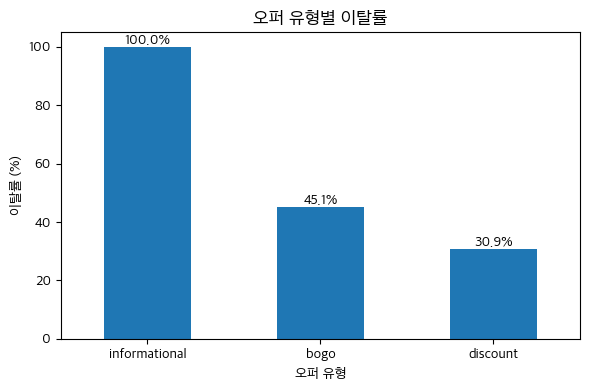

In [12]:
#오퍼 유형별 이탈률
plt.figure(figsize=(6,4))

offer_type_drop.plot(kind="bar", rot=0)

plt.title("오퍼 유형별 이탈률", fontsize=13)
plt.ylabel("이탈률 (%)")
plt.xlabel("오퍼 유형")

for i, v in enumerate(offer_type_drop.values):
    plt.text(i, v + 1, f"{v}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

📊 오퍼 유형별 이탈률 분석 (Offer Type)

▪️ 그래프 축 설명
	•	X축: 오퍼 유형 (informational, bogo, discount)
	•	Y축: Viewed 이후 오퍼를 완료하지 못한 비율 (Drop-off Rate, %)

▪️ 분석 기준 및 방법
	•	분석 단위는 person × offer
	•	오퍼를 Viewed(확인) 한 고객만을 분석 대상으로 제한
	•	각 오퍼 유형별로
Viewed → Completed 실패 여부(is_dropoff)의 평균을 계산하여 이탈률 산출
	•	오퍼 유형 간 구조적인 차이를 비교하기 위해 막대그래프로 시각화

▪️ 결과 해석
	•	informational 오퍼는 완료 행동을 요구하지 않는 구조로 인해 이탈률이 100%로 나타남
	•	discount 오퍼는 가장 낮은 이탈률을 보이며, 실질적인 행동 유도에 효과적
	•	오퍼 실패는 고객 특성 이전에 오퍼 유형 설계 단계에서 이미 크게 갈린다는 점을 시사함

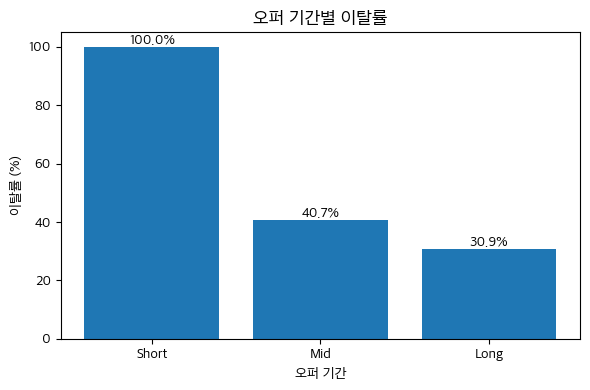

In [13]:
#오퍼기간별 (duration_bin별) 이탈률

plt.figure(figsize=(6,4))

plt.bar(
    duration_drop["duration_bin"],
    duration_drop["dropoff_rate"]
)

plt.title("오퍼 기간별 이탈률", fontsize=13)
plt.ylabel("이탈률 (%)")
plt.xlabel("오퍼 기간")

for i, v in enumerate(duration_drop["dropoff_rate"]):
    plt.text(i, v + 1, f"{v}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

📊 오퍼 기간별 이탈률 분석 (Duration)

▪️ 그래프 축 설명
	•	X축: 오퍼 기간 구간 (Short, Mid, Long)
	•	Y축: Viewed 이후 오퍼를 완료하지 못한 비율 (Drop-off Rate, %)

▪️ 분석 기준 및 방법
	•	오퍼의 duration을 기준으로 3개 구간으로 구간화
	•	Short: 짧은 기간
	•	Mid: 중간 기간
	•	Long: 긴 기간
	•	각 기간 구간별로 Viewed → Completed 실패 비율 평균을 계산
	•	오퍼 기간이 고객 행동에 미치는 영향을 비교하기 위해 막대그래프로 시각화

▪️ 결과 해석
	•	짧은 기간의 오퍼일수록 이탈률이 높게 나타남
	•	충분한 기간이 제공된 오퍼(Long)는 상대적으로 낮은 이탈률을 보임
	•	이는 오퍼 실패가 고객의 의지 부족이 아니라,
물리적으로 실행 가능한 시간 부족이라는 설계 문제에서 비롯될 가능성을 보여줌

### 오퍼 기간 구간화 기준 (Duration Binning)

본 분석에서는 오퍼의 유효 기간(duration, 일 단위)을 기준으로  
고객의 실제 행동 가능성을 반영하기 위해 다음과 같이 구간화하였다.

- Short: 1–4일  
- Mid: 5–7일  
- Long: 8–10일  

해당 구간은 데이터 내 실제 존재하는 오퍼 기간 값(3, 4, 5, 7, 10일)을 기준으로 설정되었으며,  
각 구간은 고객의 방문 주기 및 행동 실행 가능성 측면에서  
의미 있는 차이를 갖도록 정의되었다.



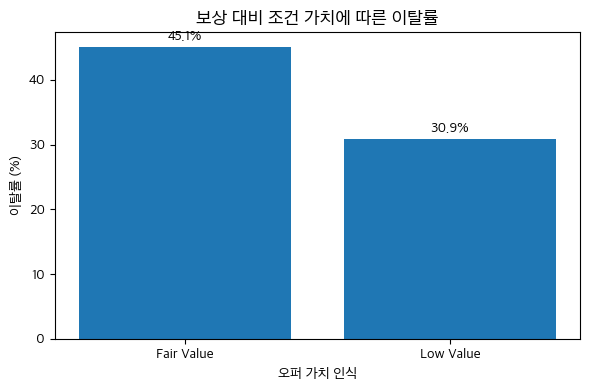

In [14]:
#보상 대비 조건 가치 이탈률
plt.figure(figsize=(6,4))

plt.bar(
    ratio_drop["ratio_bin"],
    ratio_drop["dropoff_rate"]
)

plt.title("보상 대비 조건 가치에 따른 이탈률", fontsize=13)
plt.ylabel("이탈률 (%)")
plt.xlabel("오퍼 가치 인식")

for i, v in enumerate(ratio_drop["dropoff_rate"]):
    plt.text(i, v + 1, f"{v}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

“보상이 충분해 보이는 오퍼일수록
기대가 커지고, 실패 시 이탈도 더 커집니다.”

## 📊 보상 대비 조건 가치 (Reward-to-Difficulty Ratio) 정의 및 해석

### ▪️ 보상(Reward)의 의미
- `reward`는 오퍼를 완료했을 때 고객이 얻는 실질적 보상 크기를 의미한다.
- 예:
  - 무료 음료
  - 할인 금액
- 즉, 고객 관점에서 **“이 오퍼를 달성하면 무엇을 얻는가”**에 해당하는 요소이다.

---

### ▪️ 조건(Difficulty)의 의미
- `difficulty`는 오퍼를 완료하기 위해 고객이 충족해야 하는
  최소 지출 조건 또는 행동 부담 수준을 의미한다.
- 예:
  - 일정 금액 이상 구매
  - 특정 횟수 이상 방문
- 즉, 고객 관점에서 **“이 보상을 받기 위해 얼마나 노력해야 하는가”**에 해당하는 요소이다.

---

### ▪️ 보상 대비 조건 비율의 정의
본 분석에서는 고객이 오퍼를 인지(Viewed)하는 시점에서  
보상이 조건 대비 얼마나 매력적으로 인식될 수 있는지를 수치화하기 위해  
다음과 같은 지표를 정의하였다.

\[
\text{Reward-to-Difficulty Ratio} = \frac{\text{reward}}{\text{difficulty}}
\]

- 값이 클수록:  
  → 적은 조건 대비 보상이 크다고 인식될 가능성
- 값이 작을수록:  
  → 조건 대비 보상이 충분하지 않다고 인식될 가능성

---

### ▪️ 오퍼 가치 구간화 기준
해당 비율을 기준으로 오퍼를 두 가지 유형으로 구분하였다.

- **Low Value (보상 < 조건)**  
  - `reward / difficulty < 1`  
  - 고객이 체감하는 보상 대비 조건 부담이 큰 오퍼

- **Fair Value (보상 ≥ 조건)**  
  - `reward / difficulty ≥ 1`  
  - 고객이 보상 대비 조건이 합리적이라고 인식할 가능성이 있는 오퍼

※ `difficulty = 0`인 오퍼는 실제 행동 완료 조건이 없는 구조이므로  
본 분석에서는 제외하였다.

---

### ▪️ 분석 기준 및 방법
- 분석 단위: `person × offer`
- 분석 대상: 오퍼를 **Viewed(확인)** 한 고객만 포함
- 각 가치 구간별로 Viewed → Completed 실패 여부(`is_dropoff`)의 평균을 계산하여  
  이탈률(Drop-off Rate)을 산출함.
- 이를 통해 고객이 인식하는 상대적 오퍼 가치와 실제 행동 결과 간의 관계를 비교하였다.

---

### ▪️ 결과 해석
- 보상 대비 조건이 충분하다고 인식될 수 있는 **Fair Value 오퍼에서 오히려 더 높은 이탈률**이 관찰되었다.
- 이는 보상이 클수록 Viewed 단계에서 형성되는 **기대 수준 역시 함께 상승**하기 때문으로 해석할 수 있다.
- 그러나 실제 행동 단계에서는 금액, 횟수, 기간 등의 현실적 제약으로 인해  
  기대가 충족되지 못할 경우 **기대 붕괴(expectation collapse)**가 발생하며 이탈로 이어진다.
- 즉, 오퍼 실패는 보상이 부족해서가 아니라,  
  **고객이 인식한 기대와 실제 달성 가능성 간의 괴리에서 구조적으로 발생한다.**

---

In [15]:
# person_offer 테이블 기준
funnel_summary = pd.DataFrame({
    "단계": ["Received", "Viewed", "Completed"],
    "건수": [
        person_offer["received"].sum(),
        person_offer["viewed"].sum(),
        person_offer["completed"].sum()
    ]
})

# 전환율 계산
funnel_summary["전환율(%)"] = (
    funnel_summary["건수"] / funnel_summary["건수"].iloc[0] * 100
).round(1)

funnel_summary

,단계,건수,전환율(%)
0,Received,63288,100.0
1,Viewed,49135,77.6
2,Completed,28996,45.8


---
### (첫째날 EDA 내용)
### 1. 오퍼속성 단독 분석

In [16]:
# STEP 6-1. Viewed → Completed 이탈 여부 정의

analysis_df = person_offer[
    person_offer["viewed"] == True
].copy()

analysis_df["dropoff"] = ~analysis_df["completed"]

print("분석 대상 rows:", len(analysis_df))
analysis_df["dropoff"].value_counts(normalize=True).round(3)

분석 대상 rows: 49135


dropoff
True     0.502
False    0.498
Name: proportion, dtype: float64

In [17]:
# STEP 6-2. 오퍼 속성 결합 (portfolio)

offer_attr = portfolio.copy()

# 채널 수 파생 변수
offer_attr["channel_count"] = offer_attr["channels"].apply(len)

analysis_df = analysis_df.merge(
    offer_attr[[
        "id",
        "offer_type",
        "difficulty",
        "reward",
        "duration",
        "channel_count"
    ]],
    left_on="offer_id",
    right_on="id",
    how="left"
)

# 확인
print("offer 속성 결합 후 rows:", len(analysis_df))
analysis_df[[
    "offer_type",
    "difficulty",
    "reward",
    "duration",
    "channel_count"
]].isna().mean()

offer 속성 결합 후 rows: 49135


offer_type       0.0
difficulty       0.0
reward           0.0
duration         0.0
channel_count    0.0
dtype: float64

In [51]:
# STEP 6-3-1. offer_type별 이탈률

offer_type_drop = (
    analysis_df
    .groupby("offer_type")["dropoff"]
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
)

offer_type_drop

offer_type
informational    100.0
bogo              45.1
discount          30.9
Name: dropoff, dtype: float64

## 1.오퍼 속성별 Viewed → Completed 이탈 분석 결과

본 단계에서는 고객을 고정한 상태에서  
오퍼 자체의 설계 속성이 Viewed → Completed 이탈에 어떤 영향을 미치는지를 분석하였다.

---

### (1)offer_type별 이탈률 분석 결과

| offer_type | Viewed → Completed 이탈률 |
|-----------|--------------------------|
| informational | 100.0% |
| bogo | 45.1% |
| discount | 30.9% |

#### 해석

- **informational 오퍼의 100% 이탈률은 데이터 오류가 아닌 구조적 특성**이다.  
  informational 오퍼는 행동 완료(Completed)를 요구하지 않는 오퍼로,  
  Viewed 이후 Completed 이벤트가 발생하지 않는 것이 정상적인 구조이다.
- 따라서 본 분석에서는 informational 오퍼를  
  *이탈 비교 대상이 아닌 기준(reference) 오퍼*로 해석한다.
- 행동을 요구하는 오퍼 중에서는  
  **discount 오퍼가 bogo 오퍼 대비 현저히 낮은 이탈률**을 보인다.
- 이는 동일한 Viewed 상태에서도  
  *‘즉각적인 보상 명확성’이 높은 오퍼일수록 완료로 이어질 가능성이 높다*는 점을 시사한다.

📌 **핵심 메시지**  
> “오퍼 실패는 고객 이전에, 오퍼 유형 설계 단계에서 이미 갈린다.”

---

In [18]:
# STEP 6-3-2. difficulty별 이탈률

difficulty_drop = (
    analysis_df
    .groupby("difficulty")["dropoff"]
    .mean()
    .mul(100)
    .round(1)
    .sort_index()
)

difficulty_drop

difficulty
0     100.0
5      36.6
7      29.5
10     42.0
20     38.7
Name: dropoff, dtype: float64

## (2) difficulty(난이도)별 Viewed → Completed 이탈률 분석 결과

### 📊 결과 요약

| difficulty (최소 지출 조건) | Viewed → Completed 이탈률 |
|----------------------------|---------------------------|
| 0                          | 100.0% |
| 5                          | 36.6% |
| **7**                      | **29.5% (최저)** |
| 10                         | 42.0% |
| 20                         | 38.7% |

---

### 🔍 해석

- **difficulty는 오퍼 완료를 위해 요구되는 최소 지출 금액(또는 행동 강도)**를 의미한다.  
  즉, difficulty가 높을수록 고객은 오퍼를 완료하기 위해 더 많은 비용 또는 노력을 부담해야 한다.

- difficulty = 0 구간의 **100% 이탈**은  
  실제 구매 완료를 요구하지 않는 오퍼(예: informational)에서 발생한 **구조적 결과**로,  
  데이터 오류가 아닌 **기준(reference) 수준**으로 해석한다.

- 행동 완료를 요구하는 오퍼(difficulty ≥ 5)에서는  
  이탈률이 단조 증가하지 않고 **비선형적인 패턴**을 보인다.
  - difficulty **5~7 구간**: 상대적으로 낮은 이탈률  
  - difficulty **10 이상**: 이탈률 재상승

- 이는 오퍼 실패가  
  단순히 *“조건이 높을수록 실패한다”*기보다,  
  **고객이 인지한 ‘달성 가능성’과 ‘보상 대비 지출 부담’의 균형이 깨지는 지점에서 발생**함을 시사한다.

---

### 💡 핵심 메시지

> **오퍼 완료 실패는 지출 조건(difficulty)이 높아서가 아니라,  
> 고객이 체감하는 ‘달성 가능성 대비 보상 가치’가 무너지는 지점에서 발생한다.**

---

### ▶ 다음 분석으로의 연결

- 다음 단계에서는  
  **reward와 difficulty를 함께 고려한 교차 분석**을 통해  
  *“이 조건을 감수할 만큼 보상이 충분한가?”*라는 관점에서  
  오퍼 실패 구조를 추가로 검증한다.

In [19]:
# 필수 컬럼 확인
cols = ["difficulty", "reward", "dropoff"]
missing = [c for c in cols if c not in analysis_df.columns]
print("missing cols:", missing)

print("rows:", len(analysis_df))
print("difficulty unique:", sorted(analysis_df["difficulty"].unique())[:20])
print("reward unique:", sorted(analysis_df["reward"].unique())[:20])

missing cols: []
rows: 49135
difficulty unique: [np.int64(0), np.int64(5), np.int64(7), np.int64(10), np.int64(20)]
reward unique: [np.int64(0), np.int64(2), np.int64(3), np.int64(5), np.int64(10)]


In [20]:
# difficulty별 Viewed → Completed 이탈률(%) 계산
diff_rate = (
    analysis_df
    .groupby("difficulty")["dropoff"]
    .mean()
    .mul(100)
)

# informational 제거 (difficulty > 0)
diff_rate_pos = diff_rate[diff_rate.index > 0]

diff_rate_pos

difficulty
5     36.622762
7     29.549167
10    42.017975
20    38.666667
Name: dropoff, dtype: float64

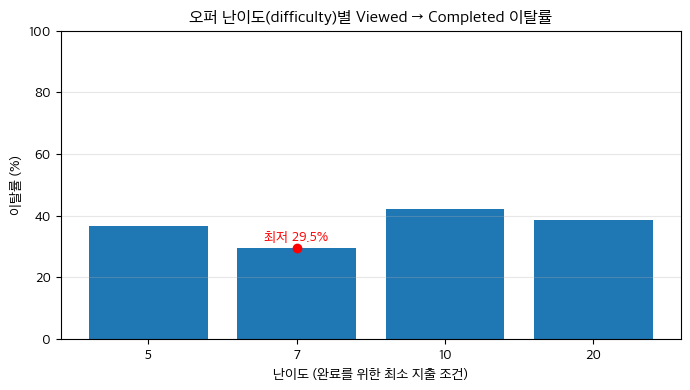

In [21]:
import matplotlib.pyplot as plt

# difficulty > 0만 사용 (informational 제거)
plot_df = diff_rate_pos.copy()

plt.figure(figsize=(8,4))
plt.bar(plot_df.index.astype(str), plot_df.values)

# 최소 이탈 강조
min_idx = plot_df.idxmin()
min_val = plot_df.loc[min_idx]

plt.scatter(str(min_idx), min_val, color="red", zorder=5)
plt.text(str(min_idx), min_val + 2, f"최저 {min_val:.1f}%", 
         ha="center", color="red")

plt.title("오퍼 난이도(difficulty)별 Viewed → Completed 이탈률")
plt.xlabel("난이도 (완료를 위한 최소 지출 조건)")
plt.ylabel("이탈률 (%)")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

plt.show()

difficulty는 오퍼 완료를 위해 요구되는 최소 지출 조건을 의미한다.<br>
분석 결과, difficulty가 높아질수록 이탈이 단조 증가하지는 않았으며,<br>
중간 수준(difficulty=7)에서 이탈률이 가장 낮은 비선형 패턴이 관찰되었다.<br>
이는 오퍼 실패가 단순히 ‘조건이 높아서’ 발생하는 것이 아니라,<br>
고객이 인지하는 달성 가능성과 보상 대비 부담의 균형이 깨지는 지점에서 발생함을 시사한다.<br>

#### 보상대비 조건(reward/difficulty)
🎯 이 단계의 목적
	•	reward / difficulty를 설계 의미가 살아있는 기준으로 이산화
	•	이후 모든 분석·발표·모델링의 기준 변수를 만든다

🔑 기준 다시 고정
	•	Low Value: 보상 < 노력 (reward_per_difficulty < 1)
	•	Fair Value: 보상 ≥ 노력 (reward_per_difficulty ≥ 1)

In [22]:
# 6-4. 같은 조건이라도 보상이 충분하면 고객은 움직이나 (보상/난이도 비율)
# difficulty > 0만 사용
ratio_df = analysis_df[
    analysis_df["difficulty"] > 0
].copy()

# 보상 대비 조건 (가성비 지표)
ratio_df["reward_per_difficulty"] = (
    ratio_df["reward"] / ratio_df["difficulty"]
)

ratio_df[["reward", "difficulty", "reward_per_difficulty"]].describe()

,reward,difficulty,reward_per_difficulty
count,39826.000000,39826.000000,39826.000000
mean,5.442475,8.921408,0.670951
std,3.170060,3.513818,0.364187
min,2.000000,5.000000,0.200000
25%,3.000000,7.000000,0.250000
50%,5.000000,10.000000,1.000000
75%,10.000000,10.000000,1.000000
max,10.000000,20.000000,1.000000


In [23]:
# STEP 6-4-0. reward_per_difficulty 생성 (analysis_df에 컬럼 추가)

analysis_df = analysis_df.copy()
analysis_df["reward_per_difficulty"] = analysis_df["reward"] / analysis_df["difficulty"]

# 확인: difficulty=0이면 inf가 생기므로 체크
analysis_df[["reward", "difficulty", "reward_per_difficulty"]].head(), \
analysis_df["reward_per_difficulty"].replace([np.inf, -np.inf], np.nan).isna().mean()

(   reward  difficulty  reward_per_difficulty
 0       0           0                    NaN
 1       0           0                    NaN
 2       5           5                    1.0
 3       2          10                    0.2
 4       5           5                    1.0,
 np.float64(0.18945761677012313))

In [24]:
# difficulty > 0만 사용 (informational/difficulty=0 제거)
ratio_df = analysis_df[analysis_df["difficulty"] > 0].copy()

ratio_df["ratio_bin"] = np.where(
    ratio_df["reward_per_difficulty"] < 1,
    "Low Value (보상 < 노력)",
    "Fair Value (보상 ≥ 노력)"
)

# 분포 확인
ratio_df["ratio_bin"].value_counts(dropna=False), ratio_df["ratio_bin"].value_counts(normalize=True).round(3)

(ratio_bin
 Fair Value (보상 ≥ 노력)    21546
 Low Value (보상 < 노력)     18280
 Name: count, dtype: int64,
 ratio_bin
 Fair Value (보상 ≥ 노력)    0.541
 Low Value (보상 < 노력)     0.459
 Name: proportion, dtype: float64)

### (3) 보상 대비 조건 비율(reward / difficulty) 기반 이탈 구조

difficulty는 오퍼 완료를 위해 요구되는 최소 지출 조건을 의미하며,  
reward_per_difficulty는 고객이 인지하는 **보상 대비 노력의 상대적 가치**를 나타낸다.

본 분석에서는 difficulty > 0 오퍼를 대상으로  
reward_per_difficulty < 1 인 경우를  
**Low Value (보상 < 노력)**,  
reward_per_difficulty ≥ 1 인 경우를  
**Fair Value (보상 ≥ 노력)** 로 구분하였다.

분석 결과, 전체 오퍼 중 약 54%는 Fair Value 구조,  
약 46%는 Low Value 구조로 나타났다.

이는 오퍼 실패가 단순히 조건이 높아서 발생하는 것이 아니라,  
고객이 인지하는 **달성 가능성 대비 보상 가치의 균형**이 깨지는 지점에서  
구조적으로 발생함을 시사한다.

In [25]:
# STEP 6-4-2. 보상 대비 조건(ratio_bin)별 Viewed → Completed 이탈률 비교

# ratio_df:
# - difficulty > 0 오퍼만 포함
# - reward_per_difficulty = reward / difficulty
# - ratio_bin:
#     Low Value  = 보상 < 노력
#     Fair Value = 보상 ≥ 노력

ratio_drop = (
    ratio_df
    .groupby("ratio_bin")["dropoff"]   # 각 보상/조건 그룹별 이탈 여부
    .mean()                            # 이탈 비율
    .mul(100)                          # %
    .round(1)
    .reset_index(name="dropoff_rate") # 발표용 컬럼명
    .sort_values("dropoff_rate", ascending=False)
)

ratio_drop

,ratio_bin,dropoff_rate
0,Fair Value (보상 ≥ 노력),45.1
1,Low Value (보상 < 노력),30.9


### (4) 보상 대비 조건 구조에 따른 이탈률 비교

reward_per_difficulty는 고객이 인지하는  
‘보상 대비 달성 부담’을 나타내는 지표이다.

분석 결과, 보상 ≥ 노력(Fair Value) 구조의 오퍼가  
보상 < 노력(Low Value) 오퍼 대비  
Viewed → Completed 단계에서 더 높은 이탈률을 보였다.

이는 Fair Value 오퍼가 더 많은 고객의 관심(Viewed)을 끌어내는 반면,  
실제 행동 단계에서는 금액·횟수·시간 등의 현실적 제약으로 인해  
기대 대비 이탈이 발생하는 구조임을 시사한다.

즉, 오퍼 실패는 단순히 보상이 부족해서가 아니라,  
고객이 형성한 기대와 실제 달성 가능성 간의 괴리가 커지는 지점에서 발생한다.

0️⃣ 지금 결과, 한 줄로 정확히 해석하면
	•	보상 ≥ 노력(Fair Value) 오퍼가
보상 < 노력(Low Value) 오퍼보다
Viewed → Completed 이탈률이 더 높다 (45.1% vs 30.9%)

👉 이건 오류도 아니고, 해석 실수도 아님.
👉 **“기대가 큰 오퍼일수록, 기대가 깨질 때 이탈이 커진다”**는 구조적 신호야.

3️⃣ 아래 리워드 단독 분석까지 본 다음의 해석
	•	본 결과는 “보상이 충분하면 고객이 더 잘 완료한다”는
단순 가설과 반대되는 패턴을 보인다.
	•	이는 보상 수준이 높을수록 Viewed 단계에서 형성되는 기대치 역시 함께 상승하기 때문으로 해석할 수 있다.
	•	그러나 실제 행동 단계에서는
금액, 횟수, 기간 등의 현실적 제약으로 인해
고객이 인지한 기대가 충족되지 못하는 순간,
**기대 붕괴(expectation collapse)**가 발생하며 이탈로 이어진다.
	•	즉, 오퍼 실패는 보상이 부족해서가 아니라,
보상이 클수록 ‘기대가 깨질 때의 실망 폭’이 더 커지는 구조에서 발생한다.

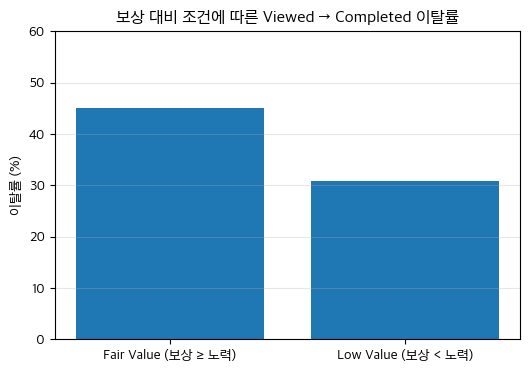

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(
    ratio_drop["ratio_bin"],
    ratio_drop["dropoff_rate"]
)

plt.title("보상 대비 조건에 따른 Viewed → Completed 이탈률")
plt.ylabel("이탈률 (%)")
plt.ylim(0, 60)
plt.grid(axis="y", alpha=0.3)

plt.show()

### reward 단독 분석 
난이도 해석을 왜곡하지 않기 위해,
보상 자체가 Viewed → Completed 이탈에 어떤 영향을 갖는지 분리 확인

⚠️ 여기서의 포인트
	•	“보상이 클수록 좋다”를 증명하려는 게 아님
	•	**보상만으로 설명 가능한가? → 아니면 한계가 있는가?**를 보는 것

In [27]:
#reward 값 분포 확인
analysis_df["reward"].value_counts().sort_index()

reward
0      9309
2      9758
3      6122
5     12118
10    11828
Name: count, dtype: int64

In [28]:
#리워드별 이탈률 테이블

reward_drop = (
    analysis_df
    .groupby("reward")["dropoff"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index(name="dropoff_rate")
    .sort_values("reward")
)

reward_drop

,reward,dropoff_rate
0,0,100.0
1,2,29.8
2,3,29.5
3,5,37.0
4,10,52.1


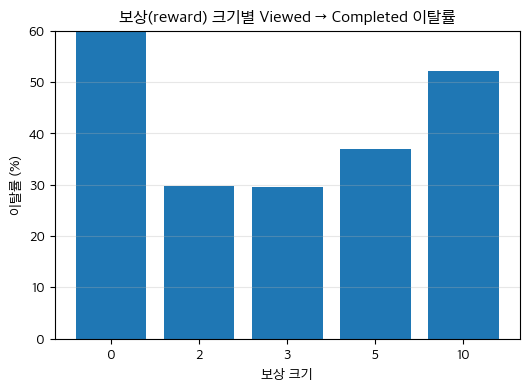

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(
    reward_drop["reward"].astype(str),
    reward_drop["dropoff_rate"]
)

plt.title("보상(reward) 크기별 Viewed → Completed 이탈률")
plt.xlabel("보상 크기")
plt.ylabel("이탈률 (%)")
plt.ylim(0, 60)
plt.grid(axis="y", alpha=0.3)

plt.show()

---
#### duration과 이탈률 분석
🎯 분석 목적 (다시 고정)

오퍼 지속 기간(duration)이
Viewed → Completed 이탈에 영향을 미치는지 확인한다.

In [30]:
#duration 구조 먼저 확인
analysis_df["duration"].value_counts().sort_index()

duration
3      5674
4      3635
5     12192
7     19084
10     8550
Name: count, dtype: int64

In [31]:
# duration 의미 기반 구간화
analysis_df["duration_bin"] = pd.cut(
    analysis_df["duration"],
    bins=[0, 4, 7, 10],
    labels=["Short", "Mid", "Long"],
    right=True
)

analysis_df["duration_bin"].value_counts()

duration_bin
Mid      31276
Short     9309
Long      8550
Name: count, dtype: int64

In [32]:
#duration 구간별 이탈률
duration_drop = (
    analysis_df
    .groupby("duration_bin")["dropoff"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index(name="dropoff_rate")
)

duration_drop

/var/folders/dl/2hxyxgtd0vbcrnl54xbdbz7h0000gn/T/ipykernel_3495/4046692047.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("duration_bin")["dropoff"]


,duration_bin,dropoff_rate
0,Short,100.0
1,Mid,40.7
2,Long,30.9


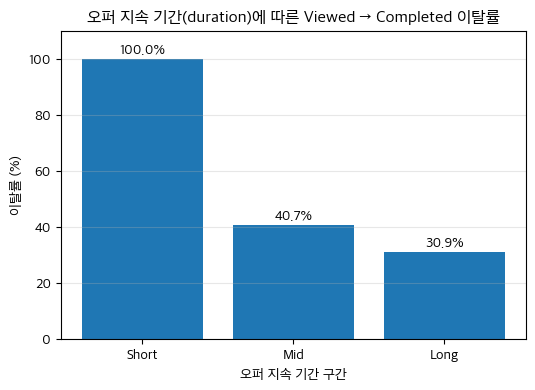

In [33]:
import matplotlib.pyplot as plt

# 데이터 준비
plot_df = duration_drop.copy()

plt.figure(figsize=(6, 4))
plt.bar(
    plot_df["duration_bin"],
    plot_df["dropoff_rate"]
)

# 값 표시
for i, row in plot_df.iterrows():
    plt.text(
        row["duration_bin"],
        row["dropoff_rate"] + 2,
        f"{row['dropoff_rate']}%",
        ha="center"
    )

plt.title("오퍼 지속 기간(duration)에 따른 Viewed → Completed 이탈률")
plt.xlabel("오퍼 지속 기간 구간")
plt.ylabel("이탈률 (%)")
plt.ylim(0, 110)
plt.grid(axis="y", alpha=0.3)

plt.show()

### (duration) 오퍼 지속 기간별 Viewed → Completed 이탈 분석

본 분석에서는 오퍼 지속 기간(duration)이  
Viewed → Completed 이탈에 미치는 영향을 확인하였다.

분석 결과, duration이 짧을수록 이탈이 높고,  
충분한 기간이 주어질수록 이탈률은 감소하는 패턴이 관찰되었다.

- Short(3–4일) 오퍼는 Viewed 이후 **100% 이탈**을 보였으며,  
  이는 고객의 의지 문제가 아닌 **물리적으로 완료가 어려운 설계 조건**에 기인한 구조적 결과이다.
- Mid(5–7일) 구간에서는 이탈률이 40.7%로 감소하였다.
- Long(10일) 오퍼는 가장 낮은 이탈률(30.9%)을 보여,  
  **충분한 시간적 여유가 오퍼 완료 가능성을 높이는 요인**임을 시사한다.

즉, 오퍼 실패는 기간이 길어서가 아니라  
기간이 짧아 고객에게 ‘실행 가능성’을 제공하지 못할 때 발생한다.

---
#### channel_count별 이탈 분석

	•	channels = 오퍼가 전달되는 채널 목록 (["web", "email", "mobile", "social"])
	•	channel_count = 그 리스트 길이

In [34]:
# channel_count별 이탈률 계산
channel_dropoff = (
    analysis_df
    .groupby("channel_count")["dropoff"]
    .mean()
    .mul(100)
)

channel_dropoff

channel_count
2    38.666667
3    65.147501
4    37.761609
Name: dropoff, dtype: float64

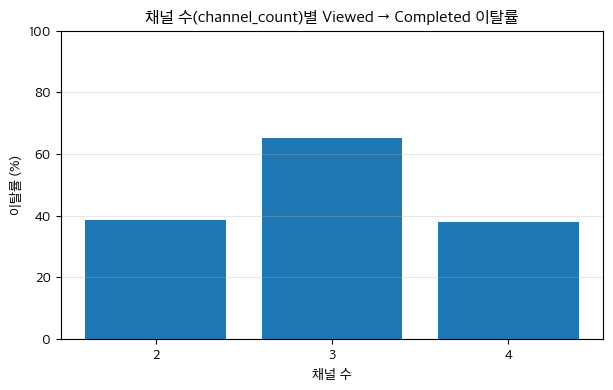

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.bar(channel_dropoff.index.astype(str), channel_dropoff.values)

plt.title("채널 수(channel_count)별 Viewed → Completed 이탈률")
plt.xlabel("채널 수")
plt.ylabel("이탈률 (%)")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

plt.show()

본 데이터셋의 오퍼는 모두 복수 채널을 통해 전달되며,
채널 수는 2~4개로 제한되어 있다.
채널 수 증가만으로 Viewed → Completed 이탈이 일관되게 감소하지는 않았으며,
노출 범위 확대 자체보다 오퍼 조건과 고객 맥락이 더 중요한 요인임을 시사한다.


In [38]:
# portfolio에서 channels 풀기 (one-hot encoding)
channels_ohe = (
    portfolio[["id", "channels"]]
    .explode("channels")
    .assign(value=1)
    .pivot_table(
        index="id",
        columns="channels",
        values="value",
        fill_value=0
    )
    .reset_index()
)

In [39]:
#analysis_df에 merge

analysis_df = analysis_df.merge(
    channels_ohe,
    left_on="offer_id",
    right_on="id",
    how="left"
)

In [40]:
analysis_df[["email", "mobile", "web", "social"]].mean()

email     1.000000
mobile    0.951155
web       0.768597
social    0.729297
dtype: float64

In [41]:
# 채널 수별 이탈률 테이블
channel_types = ["email", "mobile", "web", "social"]

channel_type_dropoff = {
    ch: analysis_df.loc[analysis_df[ch] == 1, "dropoff"].mean() * 100
    for ch in channel_types
}

channel_type_dropoff

{'email': np.float64(50.21878498015672),
 'mobile': np.float64(50.81202524874291),
 'web': np.float64(42.759168542301076),
 'social': np.float64(49.57582184517497)}

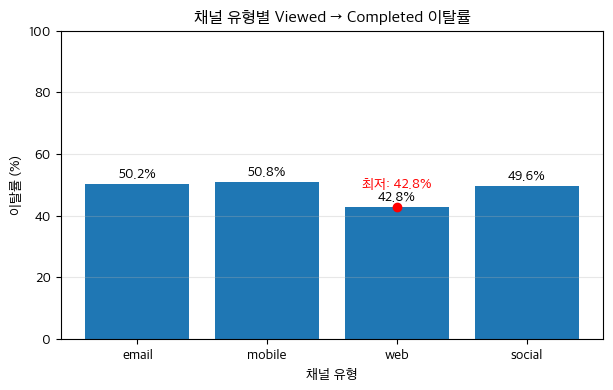

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

# 0) 전제 확인: analysis_df에 아래 컬럼들이 있어야 함
channel_types = ["email", "mobile", "web", "social"]
needed = channel_types + ["dropoff"]
missing = [c for c in needed if c not in analysis_df.columns]
if missing:
    raise KeyError(f"analysis_df에 필요한 컬럼이 없습니다: {missing}")

# 1) 채널 유형별 Viewed→Completed 이탈률(%) 계산
channel_type_dropoff = {
    ch: analysis_df.loc[analysis_df[ch] == 1, "dropoff"].mean() * 100
    for ch in channel_types
}

# 2) 시각화를 위해 Series로 변환 + 정렬(원하는 순서 유지)
plot_s = pd.Series(channel_type_dropoff).reindex(channel_types)

# 3) 바 차트
plt.figure(figsize=(7,4))
bars = plt.bar(plot_s.index, plot_s.values)

plt.title("채널 유형별 Viewed → Completed 이탈률")
plt.xlabel("채널 유형")
plt.ylabel("이탈률 (%)")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

# 4) 막대 위에 수치 표시
for b in bars:
    h = b.get_height()
    plt.text(b.get_x() + b.get_width()/2, h + 1.5, f"{h:.1f}%", ha="center", va="bottom")

# (선택) 최저 이탈 채널 강조
min_ch = plot_s.idxmin()
min_val = plot_s.min()
plt.scatter(min_ch, min_val, color="red", zorder=5)
plt.text(min_ch, min_val + 6, f"최저: {min_val:.1f}%", ha="center", color="red")

plt.show()

---
## ⏰ STEP 7. 고객 × 오퍼 교차 분석

### 분석 목적
이탈을 단순한 고객 문제 또는 오퍼 문제로 보지 않고,  
“어떤 고객이, 어떤 오퍼 조건에서 실패하는가”를 규명한다.

본 단계에서는  
Viewed → Completed 병목 구간에 집중하여  
조건부 실패 구조를 정의한다.


7-1-0. 분석 기준 재확인 (코드 전에 머릿속 정렬)
	•	단위: person × offer
	•	조건: Viewed = True
	•	타겟: Completed = False
	•	고객 축: 가입 시점 → 경험 수준
	•	오퍼 축: difficulty


In [43]:
analysis_df.shape

(49135, 22)

In [44]:
analysis_df.columns.tolist()

['person',
 'offer_id',
 'offer completed',
 'offer received',
 'offer viewed',
 'received',
 'viewed',
 'completed',
 'dropoff',
 'id_x',
 'offer_type',
 'difficulty',
 'reward',
 'duration',
 'channel_count',
 'reward_per_difficulty',
 'duration_bin',
 'id_y',
 'email',
 'mobile',
 'social',
 'web']

7-1. 고객 축을 붙인다 (merge)<br>
7-2. 의미 있는 교차쌍만 고른다 (EDA 기반)<br>
7-3. 실패 세그먼트를 '정의'한다 (라벨링)<br>
7-4. 세그먼트별 실패율 비교 & 메시지화<br>

In [45]:
# STEP 7-1-0. Viewed 이후 실패만 추출
base_df = analysis_df[
    (analysis_df["viewed"] == True) &
    (analysis_df["completed"] == False)
].copy()

base_df.shape

(24675, 22)

In [46]:
# STEP 7-1-1. 고객 속성 붙이기: join_year 생성 후 analysis_df에 merge

# 1) profile에서 join_year 만들기 (became_member_on: YYYYMMDD)
profile_tmp = profile.copy()
profile_tmp["became_member_on"] = pd.to_datetime(profile_tmp["became_member_on"], format="%Y%m%d", errors="coerce")
profile_tmp["join_year"] = profile_tmp["became_member_on"].dt.year

# (선택) 고객 세그먼트용 그룹도 같이 만들어두기
# income_group / age_group은 네가 예전에 쓰던 기준 있으면 그걸로 교체하면 됨
profile_tmp["income_group"] = pd.cut(
    profile_tmp["income"],
    bins=[0, 45000, 75000, 120000, np.inf],
    labels=["Low", "Mid-Low", "Mid-High", "High"]
)

profile_tmp["age_group"] = pd.cut(
    profile_tmp["age"],
    bins=[0, 24, 34, 44, 54, 64, np.inf],
    labels=["<25", "25-34", "35-44", "45-54", "55-64", "65+"]
)

# 2) analysis_df에 고객속성 merge (person = profile.id)
analysis_df = analysis_df.merge(
    profile_tmp[["id", "join_year", "income_group", "age_group"]],
    left_on="person",
    right_on="id",
    how="left"
)

# 3) 확인
print("analysis_df shape:", analysis_df.shape)
display(analysis_df.head())
print("join_year 결측률:", analysis_df["join_year"].isna().mean())

analysis_df shape: (49135, 26)


,person,offer_id,offer completed,offer received,offer viewed,received,viewed,completed,dropoff,id_x,...,duration_bin,id_y,email,mobile,social,web,id,join_year,income_group,age_group
0,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,NaN,336.0,372.0,True,True,False,True,3f207df678b143eea3cee63160fa8bed,...,Short,3f207df678b143eea3cee63160fa8bed,1.0,1.0,0.0,1.0,0009655768c64bdeb2e877511632db8f,2017,Mid-Low,25-34
1,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,NaN,168.0,192.0,True,True,False,True,5a8bc65990b245e5a138643cd4eb9837,...,Short,5a8bc65990b245e5a138643cd4eb9837,1.0,1.0,1.0,0.0,0009655768c64bdeb2e877511632db8f,2017,Mid-Low,25-34
2,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,414.0,408.0,456.0,True,True,True,False,f19421c1d4aa40978ebb69ca19b0e20d,...,Mid,f19421c1d4aa40978ebb69ca19b0e20d,1.0,1.0,1.0,1.0,0009655768c64bdeb2e877511632db8f,2017,Mid-Low,25-34
3,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,528.0,504.0,540.0,True,True,True,False,fafdcd668e3743c1bb461111dcafc2a4,...,Long,fafdcd668e3743c1bb461111dcafc2a4,1.0,1.0,1.0,1.0,0009655768c64bdeb2e877511632db8f,2017,Mid-Low,25-34
4,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,NaN,168.0,216.0,True,True,False,True,f19421c1d4aa40978ebb69ca19b0e20d,...,Mid,f19421c1d4aa40978ebb69ca19b0e20d,1.0,1.0,1.0,1.0,00116118485d4dfda04fdbaba9a87b5c,2018,NaN,65+


join_year 결측률: 0.0


In [47]:
# STEP 7-2-1. (실패건수) join_year × difficulty 교차 테이블

base_df = analysis_df[
    (analysis_df["viewed"] == True) &
    (analysis_df["completed"] == False)
].copy()

pivot_jy_diff = (
    base_df
    .groupby(["join_year", "difficulty"])
    .size()
    .reset_index(name="fail_count")
)

display(pivot_jy_diff.head())
print(pivot_jy_diff.shape)

,join_year,difficulty,fail_count
0,2013,0,153
1,2013,5,61
2,2013,7,10
3,2013,10,163
4,2013,20,10


(30, 3)


In [48]:
# STEP 7-2-2. join_year × difficulty 실패율 (fail / viewed) 계산

# 1) 모수: viewed = True
viewed_df = analysis_df[analysis_df["viewed"] == True].copy()

viewed_cnt = (
    viewed_df
    .groupby(["join_year", "difficulty"])
    .size()
    .reset_index(name="viewed_count")
)

# 2) 실패: viewed=True & completed=False
fail_df = analysis_df[(analysis_df["viewed"] == True) & (analysis_df["completed"] == False)].copy()

fail_cnt = (
    fail_df
    .groupby(["join_year", "difficulty"])
    .size()
    .reset_index(name="fail_count")
)

# 3) 합치고 실패율 계산
jy_diff = viewed_cnt.merge(fail_cnt, on=["join_year", "difficulty"], how="left")
jy_diff["fail_count"] = jy_diff["fail_count"].fillna(0).astype(int)
jy_diff["fail_rate"] = (jy_diff["fail_count"] / jy_diff["viewed_count"] * 100).round(1)

# 4) 확인
print("jy_diff shape:", jy_diff.shape)
display(jy_diff.sort_values(["join_year", "difficulty"]).head(10))

jy_diff shape: (30, 5)


,join_year,difficulty,viewed_count,fail_count,fail_rate
0,2013,0,153,153,100.0
1,2013,5,177,61,34.5
2,2013,7,101,10,9.9
3,2013,10,365,163,44.7
4,2013,20,28,10,35.7
5,2014,0,394,394,100.0
6,2014,5,380,127,33.4
7,2014,7,244,34,13.9
8,2014,10,915,408,44.6
9,2014,20,84,23,27.4


In [49]:
# STEP 7-2-3. 실패율 히트맵용 피벗 테이블 생성
# 목적:
# - 어떤 가입연도 × 난이도 조합에서 실패율이 '튀는지' 한눈에 보기 위함
# - 이후 PPT / 시각화 / 세그먼트 정의의 베이스 테이블

# 실패율 매트릭스
heat_fail = jy_diff.pivot(
    index="join_year",
    columns="difficulty",
    values="fail_rate"
)

# 표본 수 매트릭스 (해석 보조용)
heat_n = jy_diff.pivot(
    index="join_year",
    columns="difficulty",
    values="viewed_count"
)

# 확인
display(heat_fail)
display(heat_n)

difficulty,0,5,7,10,20
join_year,,,,,
2013,100.0,34.5,9.9,44.7,35.7
2014,100.0,33.4,13.9,44.6,27.4
2015,100.0,23.4,12.4,28.3,25.5
2016,100.0,19.7,10.2,23.6,19.7
2017,100.0,37.3,31.5,42.6,41.9
2018,100.0,56.4,52.3,62.4,57.8


difficulty,0,5,7,10,20
join_year,,,,,
2013,153,177,101,365,28
2014,394,380,244,915,84
2015,995,1079,598,2346,247
2016,1965,2014,1241,4542,542
2017,3588,3671,2382,8120,892
2018,2214,2397,1556,5298,607


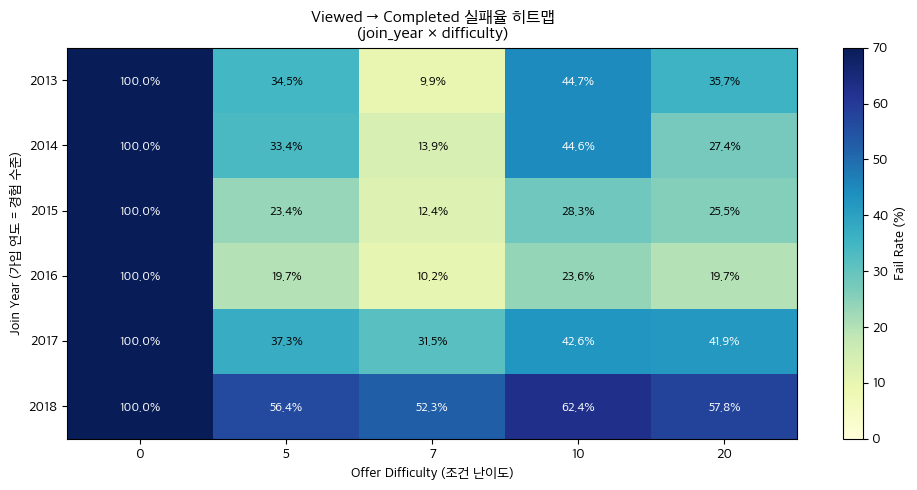

In [50]:
import matplotlib.pyplot as plt
import numpy as np

# STEP 7-2-2. Viewed → Completed 실패율 히트맵 (가독성 개선 버전)
# 목적:
# - join_year × difficulty 조합별 실패율 구조를
# - 발표용으로 한 눈에 명확하게 전달

heat_fail = (
    jy_diff
    .pivot(index="join_year", columns="difficulty", values="fail_rate")
    .sort_index()
)

plt.figure(figsize=(10, 5))

# 컬러 스케일 고정 (비교 가능성 확보)
im = plt.imshow(
    heat_fail,
    aspect="auto",
    cmap="YlGnBu",
    vmin=0,
    vmax=70
)

# 축 설정
plt.xticks(
    ticks=np.arange(len(heat_fail.columns)),
    labels=heat_fail.columns
)
plt.yticks(
    ticks=np.arange(len(heat_fail.index)),
    labels=heat_fail.index
)

# 숫자 표시 (배경 밝기에 따라 글자색 변경)
for i in range(len(heat_fail.index)):
    for j in range(len(heat_fail.columns)):
        val = heat_fail.iloc[i, j]
        if not np.isnan(val):
            text_color = "white" if val > 40 else "black"
            plt.text(
                j, i,
                f"{val:.1f}%",
                ha="center",
                va="center",
                color=text_color,
                fontsize=9,
                fontweight="bold"
            )

plt.colorbar(im, label="Fail Rate (%)")
plt.title("Viewed → Completed 실패율 히트맵\n(join_year × difficulty)")
plt.xlabel("Offer Difficulty (조건 난이도)")
plt.ylabel("Join Year (가입 연도 = 경험 수준)")
plt.tight_layout()
plt.show()

🧠 종합 해석 (구조적 의미)
	•	Viewed → Completed 실패는
단일 요인(난이도, 고객 특성)으로 설명되지 않는다
	•	실패는 다음 조건이 동시에 맞을 때 급격히 증가한다:

경험이 낮은 고객 × 중·고난이도 오퍼

	•	즉, 오퍼는 “나쁜 오퍼”가 아니라
특정 고객 조건에서만 실패하는 조건부 설계물

⸻

🎯 핵심 결론 (STEP 7 메시지)

Viewed 이후 실패는
고객 문제도, 오퍼 문제도 아닌
고객 경험 수준과 오퍼 난이도가 맞지 않을 때 발생하는 구조적 실패다.

In [51]:
# STEP 7-2-2-0.
# 분석 대상: 오퍼를 '본(Viewed)' 이후 '완료하지 못한(Completed=False)' 경우만 추출
# 이유: Viewed → Completed 병목 구간의 조건부 실패 구조를 보기 위함

base_df = analysis_df[
    (analysis_df["viewed"] == True) &
    (analysis_df["completed"] == False)
].copy()

base_df.shape

(24675, 26)

In [52]:
# STEP 7-2-2-1.
# income_group × difficulty 조합별 실패 건수 계산
# → 어떤 소득층이 어떤 난이도에서 많이 실패하는지 파악

fail_cnt = (
    base_df
    .groupby(["income_group", "difficulty"])
    .size()
    .reset_index(name="fail_count")
)

fail_cnt.head()

/var/folders/dl/2hxyxgtd0vbcrnl54xbdbz7h0000gn/T/ipykernel_3495/3833613016.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["income_group", "difficulty"])


,income_group,difficulty,fail_count
0,Low,0,1503
1,Low,5,647
2,Low,7,328
3,Low,10,2063
4,Low,20,87


In [53]:
# STEP 7-2-2-2.
# 동일한 income_group × difficulty 조합에서
# 'Viewed' 전체 건수를 분모로 계산해 실패율 산출

viewed_cnt = (
    analysis_df[analysis_df["viewed"] == True]
    .groupby(["income_group", "difficulty"])
    .size()
    .reset_index(name="viewed_count")
)

# 실패율 계산용 테이블 생성
income_diff = (
    fail_cnt
    .merge(viewed_cnt, on=["income_group", "difficulty"], how="left")
)

income_diff["fail_rate"] = (
    income_diff["fail_count"] / income_diff["viewed_count"] * 100
).round(1)

income_diff.head()

/var/folders/dl/2hxyxgtd0vbcrnl54xbdbz7h0000gn/T/ipykernel_3495/3993908491.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["income_group", "difficulty"])


,income_group,difficulty,fail_count,viewed_count,fail_rate
0,Low,0,1503,1503,100.0
1,Low,5,647,1521,42.5
2,Low,7,328,1071,30.6
3,Low,10,2063,3728,55.3
4,Low,20,87,208,41.8


In [62]:
# STEP 7-2-2-3.
# 히트맵 시각화를 위한 pivot 테이블 생성
# 행: income_group / 열: difficulty / 값: 실패율(%)

heat_income = income_diff.pivot(
    index="income_group",
    columns="difficulty",
    values="fail_rate"
)

heat_income

difficulty,0,5,7,10,20
income_group,,,,,
Low,100.0,42.5,30.6,55.3,41.8
Mid-Low,100.0,29.8,24.3,37.6,29.3
Mid-High,100.0,22.0,17.9,18.3,21.3
High,NaN,NaN,NaN,NaN,NaN


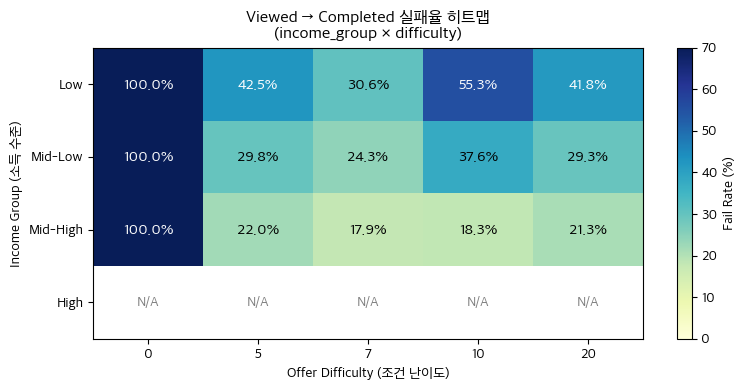

In [63]:
# STEP 7-2-1. income_group × difficulty 실패율 히트맵(숫자 가독성 개선 버전)

import pandas as pd               # pd.notna() 쓰기 위해 필요
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 4))

# 1) 히트맵 그림: heat_income(행=income_group, 열=difficulty)의 값(실패율 %)을 색으로 표현
im = plt.imshow(
    heat_income.values,           # DataFrame이면 .values로 넘겨서 matplotlib가 안정적으로 처리
    cmap="YlGnBu",
    vmin=0,
    vmax=70,
    aspect="auto"                 # 행/열 비율 때문에 칸이 찌그러지는 것 방지(가독성)
)

# 2) 축 라벨: 열/행 이름을 그대로 붙여서 해석 가능하게 만들기
plt.xticks(
    ticks=np.arange(len(heat_income.columns)),
    labels=heat_income.columns
)
plt.yticks(
    ticks=np.arange(len(heat_income.index)),
    labels=heat_income.index
)

plt.xlabel("Offer Difficulty (조건 난이도)")
plt.ylabel("Income Group (소득 수준)")
plt.title("Viewed → Completed 실패율 히트맵\n(income_group × difficulty)")

# 3) 숫자(%) 표시: 진한 칸은 흰색, 연한 칸은 검정으로 대비를 줘서 숫자 안 묻히게 하기
for i in range(heat_income.shape[0]):      # 행 개수만큼
    for j in range(heat_income.shape[1]):  # 열 개수만큼
        val = heat_income.iloc[i, j]
        if pd.notna(val):
            plt.text(
                j, i, f"{val:.1f}%",
                ha="center", va="center",
                color="white" if val >= 40 else "black",
                fontsize=11, fontweight="bold"
            )
        else:
            # 값이 없는 칸(예: High가 전부 NaN이면)에는 N/A를 찍어주면 발표에서 오해 방지
            plt.text(j, i, "N/A", ha="center", va="center", color="gray", fontsize=10)

# 4) 컬러바: 색이 의미하는 실패율 범위를 명시
plt.colorbar(im, label="Fail Rate (%)")
plt.tight_layout()
plt.show()

High 소득 그룹에서는 Viewed 이후 실패 사례가 거의 발생하지 않아,
조건 난이도와 무관하게 오퍼 전환이 안정적으로 이루어지는 구조가 확인되었다.
이는 오퍼 실패가 조건 자체보다 고객의 경제적 여력에 크게 의존하는 현상임을 시사한다.

✔ STEP 7-1 고객 × 오퍼 교차 구조 확인 완료
- 핵심 병목: Viewed → Completed
- 소득, 가입연도, 조건 부담에 따라 실패 구조가 달라짐

---
▶ 다음 세션 시작 시 할 일
- STEP 7-2: income_group × reward_per_difficulty
- High income 제외
- Low Value vs Fair Value 이탈률 비교
- 실패 세그먼트 2~3개 정의

✔ 실패 세그먼트 정의 완료
	•	저소득 × 고난이도 → 조건 설계 실패
	•	신규 × duration → 온보딩/학습 설계 실패

In [67]:
analysis_df if "analysis_df" in globals() else "NOT_EXIST"

,person,offer_id,offer completed,offer received,offer viewed,received,viewed,completed,dropoff,id_x,...,duration_bin,id_y,email,mobile,social,web,id,join_year,income_group,age_group
0,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,NaN,336.0,372.0,True,True,False,True,3f207df678b143eea3cee63160fa8bed,...,Short,3f207df678b143eea3cee63160fa8bed,1.0,1.0,0.0,1.0,0009655768c64bdeb2e877511632db8f,2017,Mid-Low,25-34
1,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,NaN,168.0,192.0,True,True,False,True,5a8bc65990b245e5a138643cd4eb9837,...,Short,5a8bc65990b245e5a138643cd4eb9837,1.0,1.0,1.0,0.0,0009655768c64bdeb2e877511632db8f,2017,Mid-Low,25-34
2,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,414.0,408.0,456.0,True,True,True,False,f19421c1d4aa40978ebb69ca19b0e20d,...,Mid,f19421c1d4aa40978ebb69ca19b0e20d,1.0,1.0,1.0,1.0,0009655768c64bdeb2e877511632db8f,2017,Mid-Low,25-34
3,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,528.0,504.0,540.0,True,True,True,False,fafdcd668e3743c1bb461111dcafc2a4,...,Long,fafdcd668e3743c1bb461111dcafc2a4,1.0,1.0,1.0,1.0,0009655768c64bdeb2e877511632db8f,2017,Mid-Low,25-34
4,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,NaN,168.0,216.0,True,True,False,True,f19421c1d4aa40978ebb69ca19b0e20d,...,Mid,f19421c1d4aa40978ebb69ca19b0e20d,1.0,1.0,1.0,1.0,00116118485d4dfda04fdbaba9a87b5c,2018,NaN,65+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49130,fffad4f4828548d1b5583907f2e9906b,f19421c1d4aa40978ebb69ca19b0e20d,36.0,0.0,6.0,True,True,True,False,f19421c1d4aa40978ebb69ca19b0e20d,...,Mid,f19421c1d4aa40978ebb69ca19b0e20d,1.0,1.0,1.0,1.0,fffad4f4828548d1b5583907f2e9906b,2017,Low,25-34
49131,ffff82501cea40309d5fdd7edcca4a07,0b1e1539f2cc45b7b9fa7c272da2e1d7,198.0,168.0,174.0,True,True,True,False,0b1e1539f2cc45b7b9fa7c272da2e1d7,...,Long,0b1e1539f2cc45b7b9fa7c272da2e1d7,1.0,0.0,0.0,1.0,ffff82501cea40309d5fdd7edcca4a07,2016,Mid-Low,45-54
49132,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,384.0,336.0,354.0,True,True,True,False,2906b810c7d4411798c6938adc9daaa5,...,Mid,2906b810c7d4411798c6938adc9daaa5,1.0,1.0,0.0,1.0,ffff82501cea40309d5fdd7edcca4a07,2016,Mid-Low,45-54
49133,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,504.0,504.0,534.0,True,True,True,False,9b98b8c7a33c4b65b9aebfe6a799e6d9,...,Mid,9b98b8c7a33c4b65b9aebfe6a799e6d9,1.0,1.0,0.0,1.0,ffff82501cea40309d5fdd7edcca4a07,2016,Mid-Low,45-54


In [65]:
analysis_df.columns.tolist()

['person',
 'offer_id',
 'offer completed',
 'offer received',
 'offer viewed',
 'received',
 'viewed',
 'completed',
 'dropoff',
 'id_x',
 'offer_type',
 'difficulty',
 'reward',
 'duration',
 'channel_count',
 'reward_per_difficulty',
 'duration_bin',
 'id_y',
 'email',
 'mobile',
 'social',
 'web',
 'id',
 'join_year',
 'income_group',
 'age_group']

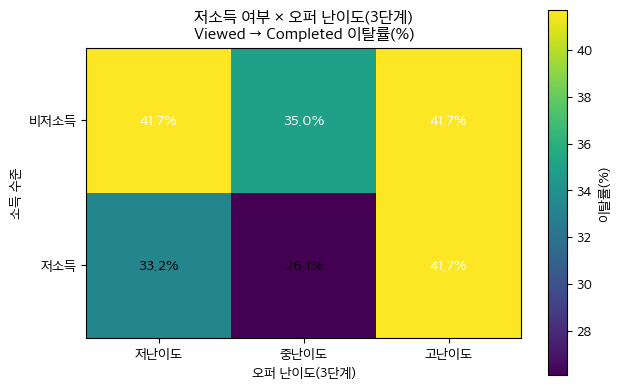

,is_low_income,difficulty_bin3,viewed_count,dropoff_rate
0,False,고난이도,9518,41.7
1,False,저난이도,3933,41.7
2,False,중난이도,2359,35.0
3,True,고난이도,14468,41.7
4,True,저난이도,5785,33.2
5,True,중난이도,3763,26.1


difficulty_bin3,저난이도,중난이도,고난이도
is_low_income,,,
False,41.7,35.0,41.7
True,33.2,26.1,41.7


In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# (옵션) display가 없어서 에러나는 환경 방지
try:
    from IPython.display import display
except:
    display = print

# =========================================================
# 저소득 여부 × 난이도(3단계) Viewed → Completed 이탈률 히트맵
# 단위: person×offer, 조건: viewed=True, 타겟: dropoff(True=이탈)
# =========================================================

# 0) 필수 컬럼 체크 (네 DF에 맞춤: dropoff 사용)
need_cols = ["viewed", "dropoff", "difficulty"]
missing = [c for c in need_cols if c not in analysis_df.columns]
if missing:
    raise KeyError(f"analysis_df에 필수 컬럼이 없음: {missing}")

tmp = analysis_df.copy()

# 1) 저소득 플래그 준비
# - is_low_income 있으면 사용
# - 없으면 income_group이 있어야 함 (Low/Mid-Low를 저소득으로 정의)
if "is_low_income" in tmp.columns:
    tmp["is_low_income"] = tmp["is_low_income"].astype(bool)
else:
    if "income_group" not in tmp.columns:
        raise KeyError("is_low_income도 없고 income_group도 없어서 저소득 정의를 못함")
    tmp["is_low_income"] = tmp["income_group"].isin(["Low", "Mid-Low"])

# 2) difficulty=0 제외 + viewed=True만 사용
tmp2 = tmp[(tmp["viewed"] == True) & (tmp["difficulty"] > 0)].copy()
tmp2["difficulty"] = tmp2["difficulty"].astype(int)

# 3) 난이도 3단계 bin
def diff_bin(x: int) -> str:
    if x <= 5:
        return "저난이도"
    elif x <= 7:
        return "중난이도"
    else:
        return "고난이도"

tmp2["difficulty_bin3"] = tmp2["difficulty"].apply(diff_bin)

# 4) 조합별 이탈률(%) 계산
ct = (
    tmp2.groupby(["is_low_income", "difficulty_bin3"], as_index=False)
        .agg(
            viewed_count=("dropoff", "size"),
            dropoff_rate=("dropoff", "mean")
        )
)
ct["dropoff_rate"] = (ct["dropoff_rate"] * 100).round(1)

# 5) 히트맵 매트릭스 만들기
heat_income_diff = ct.pivot(index="is_low_income", columns="difficulty_bin3", values="dropoff_rate")
heat_income_diff = heat_income_diff.reindex(index=[False, True], columns=["저난이도", "중난이도", "고난이도"])

# 6) 히트맵 그리기
plt.figure(figsize=(6.5, 4.2))

vmin = np.nanmin(heat_income_diff.values)
vmax = np.nanmax(heat_income_diff.values)

im = plt.imshow(heat_income_diff.values, vmin=vmin, vmax=vmax)

plt.xticks(np.arange(len(heat_income_diff.columns)), heat_income_diff.columns)
plt.yticks(np.arange(len(heat_income_diff.index)), ["비저소득", "저소득"])

plt.xlabel("오퍼 난이도(3단계)")
plt.ylabel("소득 수준")
plt.title("저소득 여부 × 오퍼 난이도(3단계)\nViewed → Completed 이탈률(%)")

for i in range(heat_income_diff.shape[0]):
    for j in range(heat_income_diff.shape[1]):
        val = heat_income_diff.iloc[i, j]
        if not pd.isna(val):
            plt.text(j, i, f"{val:.1f}%", ha="center", va="center",
                     fontsize=11, fontweight="bold",
                     color="white" if val >= (vmin + vmax) / 2 else "black")
        else:
            plt.text(j, i, "N/A", ha="center", va="center", fontsize=10, color="gray")

plt.colorbar(im, label="이탈률(%)")
plt.tight_layout()
plt.show()

# 표 확인
display(ct.sort_values(["is_low_income", "difficulty_bin3"]))
display(heat_income_diff)

In [75]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

df_test1 = analysis_df[analysis_df["viewed"] == True].copy()

# 1) dropoff 컬럼 통일: is_dropoff 없으면 dropoff를 사용
if "is_dropoff" not in df_test1.columns:
    if "dropoff" in df_test1.columns:
        df_test1["is_dropoff"] = df_test1["dropoff"].astype(bool)
    else:
        raise KeyError("is_dropoff도 dropoff도 없습니다. 이탈 타겟 컬럼을 확인하세요.")

# 2) is_low_income 만들기: 이미 있으면 사용, 없으면 income_group으로 생성
if "is_low_income" not in df_test1.columns:
    if "income_group" in df_test1.columns:
        df_test1["is_low_income"] = df_test1["income_group"].isin(["Low", "Mid-Low"])
    else:
        raise KeyError("is_low_income도 income_group도 없습니다. 저소득 정의가 필요합니다.")

# 3) is_high_difficulty 만들기: 기준 difficulty>=10 (만든 슬라이드 기준과 일치)
if "is_high_difficulty" not in df_test1.columns:
    if "difficulty" in df_test1.columns:
        df_test1["is_high_difficulty"] = (df_test1["difficulty"].astype(int) >= 10)
    else:
        raise KeyError("difficulty 컬럼이 없습니다.")

# (중요) informational(difficulty=0)은 구조적으로 100%라 통계 왜곡 가능 → 제외 권장
df_test1 = df_test1[df_test1["difficulty"] > 0].copy()

# 4) 교차표 생성
ct1 = pd.crosstab(
    index=[df_test1["is_low_income"], df_test1["is_high_difficulty"]],
    columns=df_test1["is_dropoff"]
)

ct1

is_dropoff                        False  True 
is_low_income is_high_difficulty              
False         False                3825   2467
              True                 5549   3969
True          False                6647   2901
              True                 8439   6029

In [76]:
chi2, p, dof, expected = chi2_contingency(ct1)

print("Chi-square:", round(chi2, 3))
print("p-value:", p)
print("dof:", dof)

expected_df = pd.DataFrame(expected, index=ct1.index, columns=ct1.columns)
expected_df

Chi-square: 369.201
p-value: 1.0370457889860396e-79
dof: 3


is_dropoff                              False        True 
is_low_income is_high_difficulty                          
False         False               3864.368001  2427.631999
              True                5845.685733  3672.314267
True          False               5864.110882  3683.889118
              True                8885.835384  5582.164616

“저소득 × 고난이도 오퍼 조합과
Viewed → Completed 이탈은
우연히 함께 나타난 게 아니다.”
---


🟠 실패 세그먼트 2

신규 가입자 × 장기 듀레이션 오퍼

(Onboarding / 학습 설계 실패 세그먼트)

⸻

1. 세그먼트 정의

본 세그먼트는 다음 조건을 동시에 만족하는 경우로 정의한다.
	•	신규 가입자
	•	가입 연도 기준 최근 코호트 (join_year 최신)
	•	장기 듀레이션 오퍼
	•	오퍼 유효 기간이 상대적으로 긴 경우 (duration = Long)
	•	분석 구간
	•	오퍼를 조회(Viewed)했으나 완료(Completed)하지 못한 경우

📌 분석 단위: 개인 × 오퍼 (person × offer)
📌 이탈 정의: Viewed → Completed 이탈

In [81]:
import pandas as pd
import numpy as np

# display 안전장치
try:
    from IPython.display import display
except:
    display = print

df = analysis_df.copy()

# 0) is_new_user 먼저 생성 (없을 때만)
if "is_new_user" not in df.columns:
    # 1) join_year가 있으면 그걸 사용
    if "join_year" in df.columns:
        latest_year = df["join_year"].max()
        df["is_new_user"] = (df["join_year"] == latest_year)

    # 2) became_member_on이 있으면 join_year 생성 후 사용
    elif "became_member_on" in df.columns:
        df["became_member_on"] = pd.to_datetime(df["became_member_on"].astype(str), errors="coerce")
        df["join_year"] = df["became_member_on"].dt.year
        latest_year = df["join_year"].max()
        df["is_new_user"] = (df["join_year"] == latest_year)

    else:
        raise KeyError("is_new_user를 만들 수 없습니다. join_year 또는 became_member_on 컬럼이 필요합니다.")

# 1) 이제 필수 컬럼 체크 (생성 후)
required_cols = ["viewed", "completed", "is_new_user", "duration_bin"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(f"필수 컬럼이 없음: {missing}")

# 2) Viewed 표본만 추출
df_v = df[df["viewed"] == True].copy()

print("Viewed 표본 수:", len(df_v))
display(df_v[required_cols].head())
print("\n[duration_bin 분포]")
print(df_v["duration_bin"].value_counts(dropna=False))
print("\n[is_new_user 분포]")
print(df_v["is_new_user"].value_counts(dropna=False))

Viewed 표본 수: 49135


,viewed,completed,is_new_user,duration_bin
0,True,False,False,Short
1,True,False,False,Short
2,True,True,False,Mid
3,True,True,False,Long
4,True,False,True,Mid



[duration_bin 분포]
duration_bin
Mid      31276
Short     9309
Long      8550
Name: count, dtype: int64

[is_new_user 분포]
is_new_user
False    37063
True     12072
Name: count, dtype: int64


In [ ]:
# 뷰드 표본 + 이탈 변수 생성

df_v = analysis_df[analysis_df["viewed"] == True].copy()
df_v["is_dropoff"] = ~df_v["completed"]

In [85]:
# 0) is_new_user가 들어있는 df를 analysis_df에 저장(동기화)
analysis_df["is_new_user"] = df["is_new_user"].values

# 1) df_v를 다시 만들기 (이제 is_new_user 포함됨)
df_v = analysis_df[analysis_df["viewed"] == True].copy()
df_v["is_dropoff"] = ~df_v["completed"]

In [89]:
#신규 x 오퍼기간 이탈률 테이블 만들기

ct2 = (
    df_v
    .groupby(["is_new_user", "duration_bin"])
    .agg(
        count=("is_dropoff", "size"),
        dropoff_rate=("is_dropoff", "mean")
    )
    .reset_index()
)

ct2["dropoff_rate"] = (ct2["dropoff_rate"] * 100).round(1)
ct2

/var/folders/dl/2hxyxgtd0vbcrnl54xbdbz7h0000gn/T/ipykernel_3495/2194562341.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["is_new_user", "duration_bin"])


,is_new_user,duration_bin,count,dropoff_rate
0,False,Short,7095,100.0
1,False,Mid,23583,34.2
2,False,Long,6385,23.1
3,True,Short,2214,100.0
4,True,Mid,7693,60.5
5,True,Long,2165,53.9


In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Viewed 표본
df_v = analysis_df[analysis_df["viewed"] == True].copy()

# Viewed → Completed 이탈 정의
df_v["is_dropoff"] = ~df_v["completed"]

In [96]:
heat_new_duration = ct2.pivot(
    index="is_new_user",
    columns="duration_bin",
    values="dropoff_rate"
)

heat_new_duration = heat_new_duration.reindex(
    index=[False, True],
    columns=["Short", "Mid", "Long"]
)

heat_new_duration

duration_bin,Short,Mid,Long
is_new_user,,,
False,100.0,34.2,23.1
True,100.0,60.5,53.9


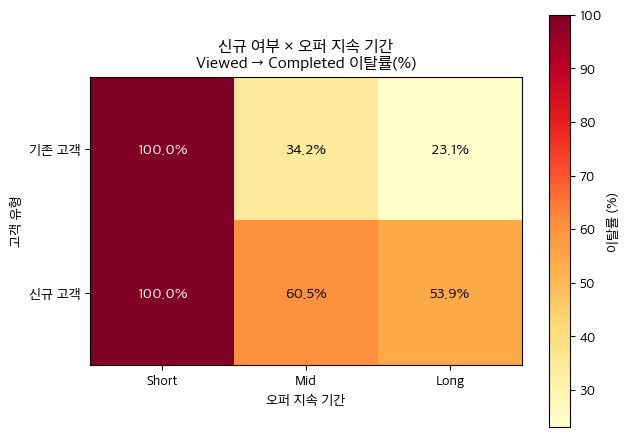

In [97]:
plt.figure(figsize=(6.5, 4.5))

vmin = np.nanmin(heat_new_duration.values)
vmax = np.nanmax(heat_new_duration.values)

im = plt.imshow(
    heat_new_duration.values,
    cmap="YlOrRd",
    vmin=vmin,
    vmax=vmax
)

plt.xticks(
    np.arange(len(heat_new_duration.columns)),
    heat_new_duration.columns
)
plt.yticks(
    np.arange(len(heat_new_duration.index)),
    ["기존 고객", "신규 고객"]
)

plt.xlabel("오퍼 지속 기간")
plt.ylabel("고객 유형")
plt.title("신규 여부 × 오퍼 지속 기간\nViewed → Completed 이탈률(%)")

# 셀 값 표시
for i in range(heat_new_duration.shape[0]):
    for j in range(heat_new_duration.shape[1]):
        val = heat_new_duration.iloc[i, j]
        if not pd.isna(val):
            plt.text(
                j, i, f"{val:.1f}%",
                ha="center", va="center",
                fontsize=11, fontweight="bold",
                color="white" if val >= (vmin + vmax) / 2 else "black"
            )
        else:
            plt.text(j, i, "N/A", ha="center", va="center", color="gray")

plt.colorbar(im, label="이탈률 (%)")
plt.tight_layout()
plt.show()

In [98]:
from scipy.stats import chi2_contingency

# 1) Long duration만 필터
df_long = df_v[df_v["duration_bin"] == "Long"].copy()

# 2) 교차표 만들기: (신규 여부) × (이탈 여부)
cont = pd.crosstab(df_long["is_new_user"], df_long["dropoff_vc"])
cont.index = ["비신규(False)", "신규(True)"]
cont.columns = ["완료(True)", "이탈(dropoff)"] if cont.shape[1] == 2 else cont.columns  # 안전장치

display(cont)

# 3) 카이제곱 검정
chi2, p, dof, expected = chi2_contingency(cont)

print(f"Chi-square = {chi2:.4f}")
print(f"p-value    = {p:.6f}")
print(f"dof        = {dof}")

# 4) 기대도수(검정 가정 체크용)도 같이 확인
expected_df = pd.DataFrame(expected, index=cont.index, columns=cont.columns)
display(expected_df.round(2))

,완료(True),이탈(dropoff)
비신규(False),4907,1478
신규(True),998,1167


Chi-square = 714.3268
p-value    = 0.000000
dof        = 1


,완료(True),이탈(dropoff)
비신규(False),4409.76,1975.24
신규(True),1495.24,669.76


In [99]:
# =========================================================
# [FINAL] master_df 생성 & 저장 (person × offer 단위)
# =========================================================

# 1) 타겟 컬럼 표준화: dropoff → is_dropoff
if "is_dropoff" not in analysis_df.columns:
    if "dropoff" in analysis_df.columns:
        analysis_df["is_dropoff"] = analysis_df["dropoff"].astype(int)
    else:
        # 혹시 completed로부터 만들 수 있게 안전장치
        analysis_df["is_dropoff"] = (~analysis_df["completed"]).astype(int)

# 2) PPT/모델에 필요한 최소 컬럼만 선택
keep_cols = [
    "person", "offer_id",
    "received", "viewed", "completed",
    "is_dropoff",

    # customer
    "join_year", "income_group", "age_group",

    # offer
    "offer_type", "difficulty", "reward", "duration", "channel_count",
    "reward_per_difficulty", "ratio_bin", "duration_bin"
]

# 없는 컬럼이 있으면 자동 제외(노트북 진행에 따라 컬럼 생성 순서가 달라질 수 있으니)
keep_cols = [c for c in keep_cols if c in analysis_df.columns]

master_df = analysis_df[keep_cols].copy()

print("master_df shape:", master_df.shape)
display(master_df.head())

# 3) 저장
master_df.to_csv("../data/processed/master_person_offer.csv", index=False)
print("[SAVED] ../data/processed/master_person_offer.csv")

master_df shape: (49135, 16)


,person,offer_id,received,viewed,completed,is_dropoff,join_year,income_group,age_group,offer_type,difficulty,reward,duration,channel_count,reward_per_difficulty,duration_bin
0,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,True,True,False,1,2017,Mid-Low,25-34,informational,0,0,4,3,NaN,Short
1,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,True,True,False,1,2017,Mid-Low,25-34,informational,0,0,3,3,NaN,Short
2,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,True,True,True,0,2017,Mid-Low,25-34,bogo,5,5,5,4,1.0,Mid
3,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,True,True,True,0,2017,Mid-Low,25-34,discount,10,2,10,4,0.2,Long
4,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,True,True,False,1,2018,NaN,65+,bogo,5,5,5,4,1.0,Mid


[SAVED] ../data/processed/master_person_offer.csv


In [100]:
import os, pandas as pd

os.makedirs("../reports/figures", exist_ok=True)

# 지금 세션에 실제로 존재하는 후보들
candidates = {
    "offer_type_drop": "offer_type_drop",
    "difficulty_drop": "difficulty_drop",
    "reward_drop": "reward_drop",
    "duration_drop": "duration_drop",
    "ratio_drop": "ratio_drop",
    "jy_diff": "join_year_x_difficulty_failrate",
    "income_diff": "income_x_difficulty_failrate",
}

for var_name, file_name in candidates.items():
    if var_name not in globals():
        print(f"[SKIP] {var_name} not defined")
        continue

    obj = globals()[var_name]

    # Series → DataFrame으로 변환
    if isinstance(obj, pd.Series):
        obj = obj.to_frame("dropoff_rate")

    obj.to_csv(f"../reports/figures/{file_name}.csv", index=False)
    print(f"[SAVED] {file_name}.csv")

[SAVED] offer_type_drop.csv
[SAVED] difficulty_drop.csv
[SAVED] reward_drop.csv
[SAVED] duration_drop.csv
[SAVED] ratio_drop.csv
[SAVED] join_year_x_difficulty_failrate.csv
[SAVED] income_x_difficulty_failrate.csv


In [101]:
import os, glob

print("reports/figures exists:", os.path.exists("../reports/figures"))
print("cwd:", os.getcwd())
print("saved csv files:", glob.glob("../reports/figures/*.csv")[:10])

reports/figures exists: True
cwd: /Users/ujpark/projects/starbucks_app_analysis/notebook
saved csv files: ['../reports/figures/reward_drop.csv', '../reports/figures/duration_drop.csv', '../reports/figures/income_x_difficulty_failrate.csv', '../reports/figures/ratio_drop.csv', '../reports/figures/join_year_x_difficulty_failrate.csv', '../reports/figures/offer_type_drop.csv', '../reports/figures/difficulty_drop.csv']
